# Day 1 - Hands-On Lab: K-Means Clustering

### Step 1: Run DBSCAN on the Day 1 dataset and report how many clusters and noise points it found.

In [2]:
from sklearn.cluster import DBSCAN
import numpy as np
import pandas as pd 
from sklearn.datasets import load_iris
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)
X = df.copy()
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

unique_labels = set(dbscan_labels)

n_clusters = len(unique_labels - {-1})
n_noise = np.sum(dbscan_labels == -1)

print("DBSCAN Results")
print("-" * 30)
print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")
from collections import Counter

print(Counter(dbscan_labels))

DBSCAN Results
------------------------------
Number of clusters: 2
Number of noise points: 17
Counter({np.int64(1): 84, np.int64(0): 49, np.int64(-1): 17})


### Step 2: Build a hierarchical clustering dendrogram and choose a cut height, noting the resulting cluster count.

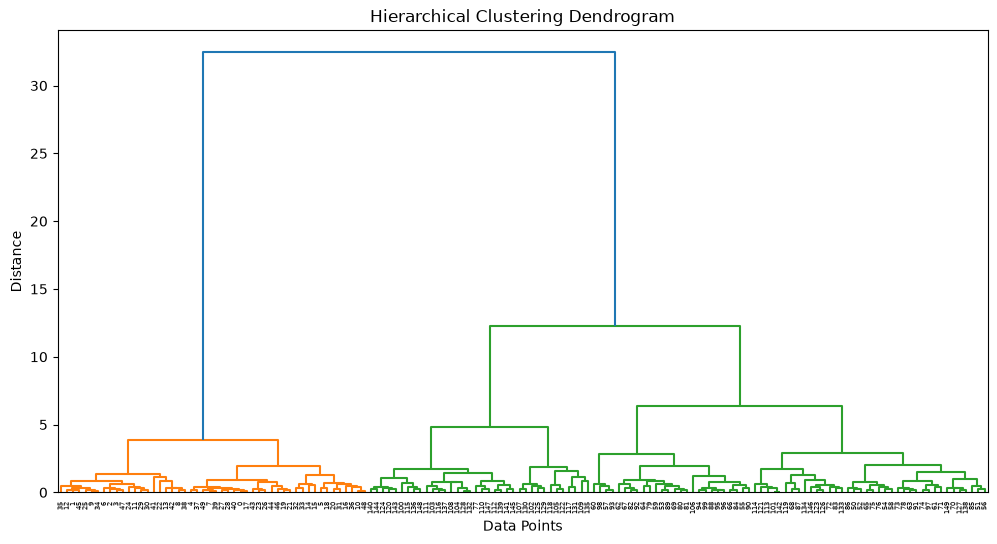

In [3]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Build hierarchical clustering
Z = linkage(X, method="ward")

# Plot dendrogram
plt.figure(figsize=(12, 6))

dendrogram(Z)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.show()

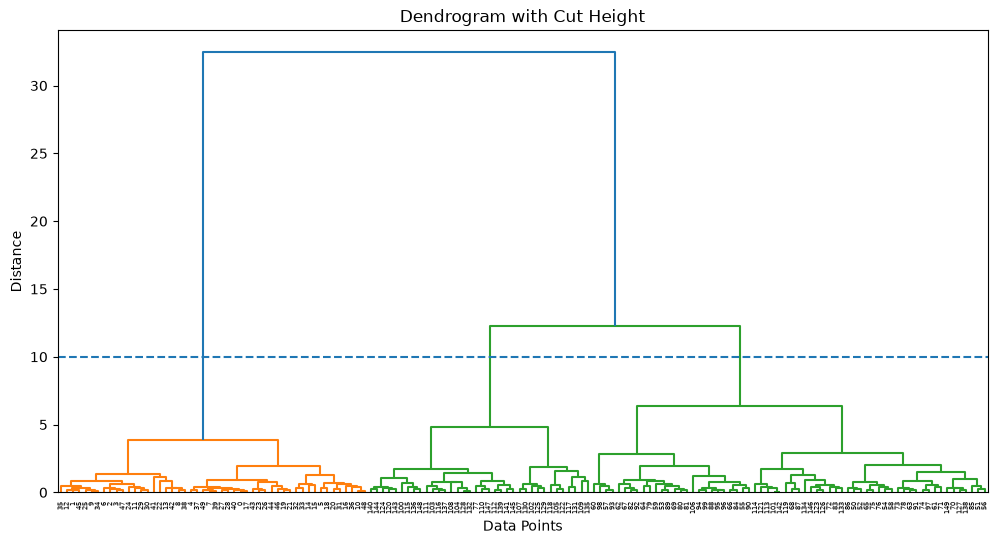

In [4]:
plt.figure(figsize=(12, 6))
cut_height = 10
dendrogram(Z)

plt.axhline(
    y=cut_height,
    linestyle="--"
)

plt.title("Dendrogram with Cut Height")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.show()

In [5]:
from scipy.cluster.hierarchy import fcluster

hierarchical_labels = fcluster(
    Z,
    t=cut_height,
    criterion="distance"
)

n_hierarchical_clusters = len(
    np.unique(hierarchical_labels)
)

print("Hierarchical Clustering Results")
print("-" * 35)
print(f"Cut height: {cut_height}")
print(f"Number of clusters: {n_hierarchical_clusters}")

Hierarchical Clustering Results
-----------------------------------
Cut height: 10
Number of clusters: 3


### Step 3: Compare the K-Means, DBSCAN, and hierarchical results on the same data.


In [6]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X)

In [7]:
print("Clustering Comparison")
print("=" * 40)

print(f"K-Means clusters: {len(np.unique(kmeans_labels))}")

print(f"DBSCAN clusters: {n_clusters}")
print(f"DBSCAN noise points: {n_noise}")

print(
    f"Hierarchical clusters: "
    f"{n_hierarchical_clusters}"
)

Clustering Comparison
K-Means clusters: 3
DBSCAN clusters: 2
DBSCAN noise points: 17
Hierarchical clusters: 3


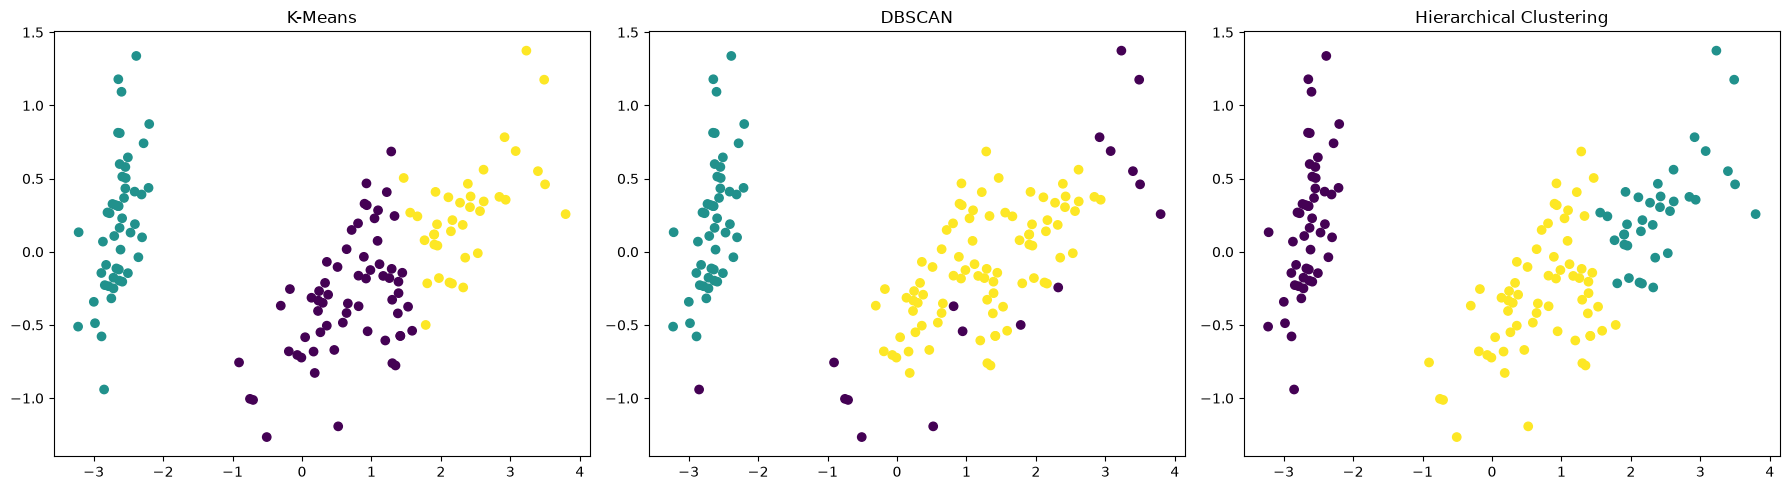

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_2d = pca.fit_transform(X)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=kmeans_labels
)
axes[0].set_title("K-Means")


axes[1].scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=dbscan_labels
)
axes[1].set_title("DBSCAN")


axes[2].scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=hierarchical_labels
)
axes[2].set_title("Hierarchical Clustering")

plt.tight_layout()
plt.show()

### Step 4: In Markdown, state which method best fits this dataset's shape and why.

We applied K-Means, DBSCAN, and Hierarchical Clustering to the same dataset.

### K-Means

K-Means produced 3 clusters. However, K-Means requires the number of
clusters to be specified in advance and assigns every data point to a
cluster. Therefore, it identified no noise points.

### DBSCAN

DBSCAN identified 2 clusters and 17 noise points.

The distribution was:

- Cluster 0: 49 points
- Cluster 1: 84 points
- Noise: 17 points

The 17 noise points were not forced into either cluster. This is an
important advantage when the dataset contains outliers or sparse regions.

### Hierarchical Clustering

Hierarchical clustering produced 3 clusters when the dendrogram was cut
at a height of 10.

Unlike K-Means, hierarchical clustering builds a hierarchy of clusters
and allows us to choose the number of clusters by selecting a cut height
from the dendrogram.

### Comparison

| Method | Number of Clusters | Noise Points |
|--------|--------------------|--------------|
| K-Means | 3 | 0 |
| DBSCAN | 2 | 17 |
| Hierarchical | 3 | Not explicitly detected |

### Conclusion

DBSCAN is a strong choice for this dataset if the 17 detected noise
points correspond to actual outliers or sparse regions.

Its main advantage is that it does not require the number of clusters
to be specified in advance and can explicitly identify noise points.

K-Means is simpler and works well when clusters are approximately
spherical and similarly sized, but it forces every point into a cluster.

Hierarchical clustering is useful for understanding the structure and
relationships between observations through the dendrogram, but it does
not explicitly identify noise points like DBSCAN.